**HH Model**



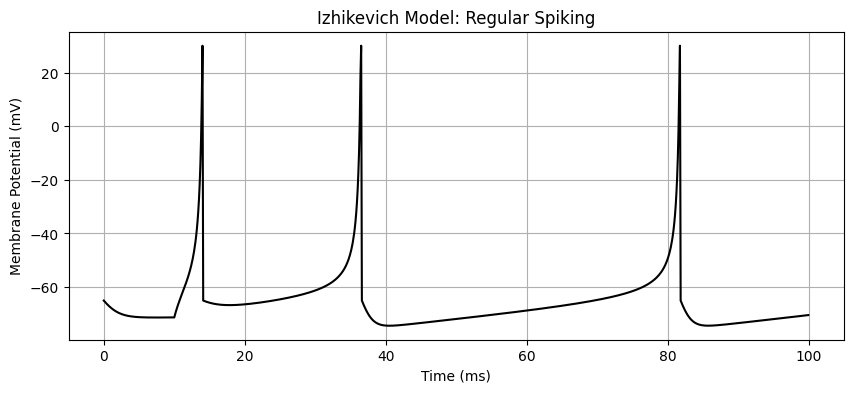

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
T = 100.0          # Total time in ms
dt = 0.1           # Time step in ms
steps = int(T/dt)
time = np.arange(0, T, dt)

# Izhikevich Parameters for 'Regular Spiking' (RS)
a = 0.02
b = 0.2
c = -65.0
d = 8.0

# Arrays to hold variables
v = np.zeros(steps)
u = np.zeros(steps)
v[0] = -65.0       # Resting potential
u[0] = b * v[0]

# Input current: 0 for first 10ms, then 10 uA
I = np.concatenate((np.zeros(int(10/dt)), 10 * np.ones(steps - int(10/dt))))

# Euler Integration Loop
for i in range(steps - 1):
    if v[i] >= 30.0:        # Spike reached
        v[i] = 30.0         # Set peak for the plot
        v[i+1] = c          # Reset voltage
        u[i+1] = u[i] + d   # Reset recovery variable
    else:
        # Differential equations
        dv = (0.04 * v[i]**2) + (5 * v[i]) + 140 - u[i] + I[i]
        du = a * (b * v[i] - u[i])

        v[i+1] = v[i] + (dv * dt)
        u[i+1] = u[i] + (du * dt)

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(time, v, color='black')
plt.title("Izhikevich Model: Regular Spiking")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.grid(True)
plt.show()

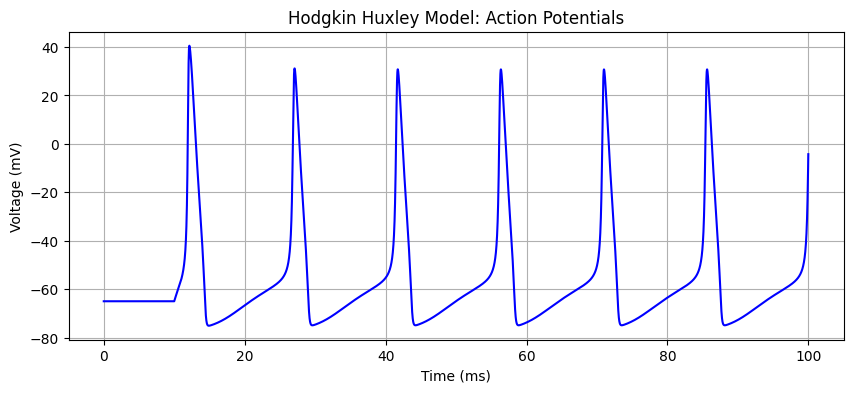

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
T = 100.0
dt = 0.01          # Smaller time step needed for HH stability
steps = int(T/dt)
time = np.arange(0, T, dt)

# Biophysical Constants
C_m = 1.0          # Membrane capacitance (uF/cm^2)
g_Na = 120.0       # Max Na conductance (mS/cm^2)
g_K = 36.0         # Max K conductance (mS/cm^2)
g_L = 0.3          # Max Leak conductance (mS/cm^2)
E_Na = 50.0        # Na reversal potential (mV)
E_K = -77.0        # K reversal potential (mV)
E_L = -54.387      # Leak reversal potential (mV)

# Arrays and initial conditions
V = np.zeros(steps)
m = np.zeros(steps)
n = np.zeros(steps)
h = np.zeros(steps)
V[0] = -65.0       # Resting potential

# Initializing gating variables to steady state at resting potential
alpha_m = 0.1 * (V[0] + 40.0) / (1.0 - np.exp(-(V[0] + 40.0) / 10.0))
beta_m = 4.0 * np.exp(-(V[0] + 65.0) / 18.0)
m[0] = alpha_m / (alpha_m + beta_m)

alpha_h = 0.07 * np.exp(-(V[0] + 65.0) / 20.0)
beta_h = 1.0 / (1.0 + np.exp(-(V[0] + 35.0) / 10.0))
h[0] = alpha_h / (alpha_h + beta_h)

alpha_n = 0.01 * (V[0] + 55.0) / (1.0 - np.exp(-(V[0] + 55.0) / 10.0))
beta_n = 0.125 * np.exp(-(V[0] + 65.0) / 80.0)
n[0] = alpha_n / (alpha_n + beta_n)

# Input current: 0 for first 10ms, then 10 uA
I_ext = np.concatenate((np.zeros(int(10/dt)), 10 * np.ones(steps - int(10/dt))))

# Euler Integration Loop
for i in range(steps - 1):
    # Calculate voltage dependent transition rates
    a_m = 0.1 * (V[i] + 40.0) / (1.0 - np.exp(-(V[i] + 40.0) / 10.0)) if V[i] != -40.0 else 1.0
    b_m = 4.0 * np.exp(-(V[i] + 65.0) / 18.0)
    a_h = 0.07 * np.exp(-(V[i] + 65.0) / 20.0)
    b_h = 1.0 / (1.0 + np.exp(-(V[i] + 35.0) / 10.0))
    a_n = 0.01 * (V[i] + 55.0) / (1.0 - np.exp(-(V[i] + 55.0) / 10.0)) if V[i] != -55.0 else 0.1
    b_n = 0.125 * np.exp(-(V[i] + 65.0) / 80.0)

    # Calculate ionic currents
    I_Na = g_Na * (m[i]**3) * h[i] * (V[i] - E_Na)
    I_K = g_K * (n[i]**4) * (V[i] - E_K)
    I_L = g_L * (V[i] - E_L)

    # Update variables
    V[i+1] = V[i] + dt * (1.0 / C_m) * (I_ext[i] - (I_Na + I_K + I_L))
    m[i+1] = m[i] + dt * (a_m * (1.0 - m[i]) - b_m * m[i])
    h[i+1] = h[i] + dt * (a_h * (1.0 - h[i]) - b_h * h[i])
    n[i+1] = n[i] + dt * (a_n * (1.0 - n[i]) - b_n * n[i])

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(time, V, color='blue')
plt.title("Hodgkin Huxley Model: Action Potentials")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

**Izhikevich Model**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr

def simulate_izhikevich(a, b, c, d, I_app, duration):
    # Setup time
    dt = 0.1
    steps = int(duration / dt)
    time = np.arange(0, duration, dt)

    # Initialize arrays
    v = np.zeros(steps)
    u = np.zeros(steps)
    v[0] = -65.0
    u[0] = b * v[0]

    # Setup applied current (starts at 10ms)
    I = np.zeros(steps)
    start_idx = int(10 / dt)
    if start_idx < steps:
        I[start_idx:] = I_app

    # Euler integration
    for i in range(steps - 1):
        if v[i] >= 30.0:
            v[i] = 30.0
            v[i+1] = c
            u[i+1] = u[i] + d
        else:
            dv = (0.04 * v[i]**2) + (5 * v[i]) + 140 - u[i] + I[i]
            du = a * (b * v[i] - u[i])
            v[i+1] = v[i] + dv * dt
            u[i+1] = u[i] + du * dt

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(time, v, color='black')
    ax.set_title(f"Izhikevich Model (a={a}, b={b}, c={c}, d={d})")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Membrane Potential (mV)")
    ax.grid(True)
    plt.tight_layout()

    return fig

# Build the Gradio App
with gr.Blocks(theme=gr.themes.Soft()) as izhikevich_app:
    gr.Markdown("## Izhikevich Model Live Simulation")
    gr.Markdown("Adjust the parameters to change the neuron's spiking behavior.")

    with gr.Row():
        with gr.Column():
            a_slider = gr.Slider(0.01, 0.1, value=0.02, step=0.01, label="a (Time scale of recovery)")
            b_slider = gr.Slider(0.1, 0.3, value=0.2, step=0.01, label="b (Sensitivity of recovery)")
            c_slider = gr.Slider(-70, -40, value=-65, step=1, label="c (Reset voltage)")
            d_slider = gr.Slider(0.1, 10, value=8, step=0.1, label="d (After-spike reset)")
            I_slider = gr.Slider(0, 20, value=10, step=1, label="Applied Current (uA)")
            dur_slider = gr.Slider(50, 500, value=100, step=10, label="Simulation Duration (ms)")
            run_btn = gr.Button("Simulate Neuron", variant="primary")

        with gr.Column():
            output_plot = gr.Plot(label="Voltage Trace")

    # Connect inputs to function
    run_btn.click(
        fn=simulate_izhikevich,
        inputs=[a_slider, b_slider, c_slider, d_slider, I_slider, dur_slider],
        outputs=output_plot
    )

# Launch the app
izhikevich_app.launch(share=False)

/tmp/ipython-input-308/2929323783.py:47: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as izhikevich_app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr

def simulate_hh(I_app, g_Na_max, g_K_max, duration):
    # Setup time
    dt = 0.01
    steps = int(duration / dt)
    time = np.arange(0, duration, dt)

    # Constants
    C_m = 1.0
    g_L = 0.3
    E_Na = 50.0
    E_K = -77.0
    E_L = -54.387

    # Initialize arrays
    V = np.zeros(steps)
    m = np.zeros(steps)
    h = np.zeros(steps)
    n = np.zeros(steps)
    V[0] = -65.0

    # Approximate steady state for initial gating variables
    m[0] = 0.05
    h[0] = 0.6
    n[0] = 0.32

    # Setup applied current
    I_ext = np.zeros(steps)
    start_idx = int(10 / dt)
    if start_idx < steps:
        I_ext[start_idx:] = I_app

    # Euler integration
    for i in range(steps - 1):
        # Rate functions
        a_m = 0.1 * (V[i] + 40.0) / (1.0 - np.exp(-(V[i] + 40.0) / 10.0)) if V[i] != -40.0 else 1.0
        b_m = 4.0 * np.exp(-(V[i] + 65.0) / 18.0)
        a_h = 0.07 * np.exp(-(V[i] + 65.0) / 20.0)
        b_h = 1.0 / (1.0 + np.exp(-(V[i] + 35.0) / 10.0))
        a_n = 0.01 * (V[i] + 55.0) / (1.0 - np.exp(-(V[i] + 55.0) / 10.0)) if V[i] != -55.0 else 0.1
        b_n = 0.125 * np.exp(-(V[i] + 65.0) / 80.0)

        # Currents
        I_Na = g_Na_max * (m[i]**3) * h[i] * (V[i] - E_Na)
        I_K = g_K_max * (n[i]**4) * (V[i] - E_K)
        I_L = g_L * (V[i] - E_L)

        # Update
        V[i+1] = V[i] + dt * (1.0 / C_m) * (I_ext[i] - (I_Na + I_K + I_L))
        m[i+1] = m[i] + dt * (a_m * (1.0 - m[i]) - b_m * m[i])
        h[i+1] = h[i] + dt * (a_h * (1.0 - h[i]) - b_h * h[i])
        n[i+1] = n[i] + dt * (a_n * (1.0 - n[i]) - b_n * n[i])

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(time, V, color='blue')
    ax.set_title("Hodgkin-Huxley Model")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Voltage (mV)")
    ax.grid(True)
    plt.tight_layout()

    return fig

# Build the Gradio App
with gr.Blocks(theme=gr.themes.Soft()) as hh_app:
    gr.Markdown("## Hodgkin-Huxley Model Live Simulation")
    gr.Markdown("Adjust the applied current and ion channel conductances.")

    with gr.Row():
        with gr.Column():
            I_slider = gr.Slider(0, 50, value=10, step=1, label="Applied Current (uA)")
            g_Na_slider = gr.Slider(0, 150, value=120, step=5, label="Max Na+ Conductance (g_Na)")
            g_K_slider = gr.Slider(0, 50, value=36, step=2, label="Max K+ Conductance (g_K)")
            dur_slider = gr.Slider(50, 200, value=100, step=10, label="Simulation Duration (ms)")
            run_btn = gr.Button("Simulate Circuit", variant="primary")

        with gr.Column():
            output_plot = gr.Plot(label="Voltage Trace")

    # Connect inputs to function
    run_btn.click(
        fn=simulate_hh,
        inputs=[I_slider, g_Na_slider, g_K_slider, dur_slider],
        outputs=output_plot
    )

# Launch the app
hh_app.launch(share=False)

/tmp/ipython-input-598/2677115955.py:69: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as hh_app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

live comparison code


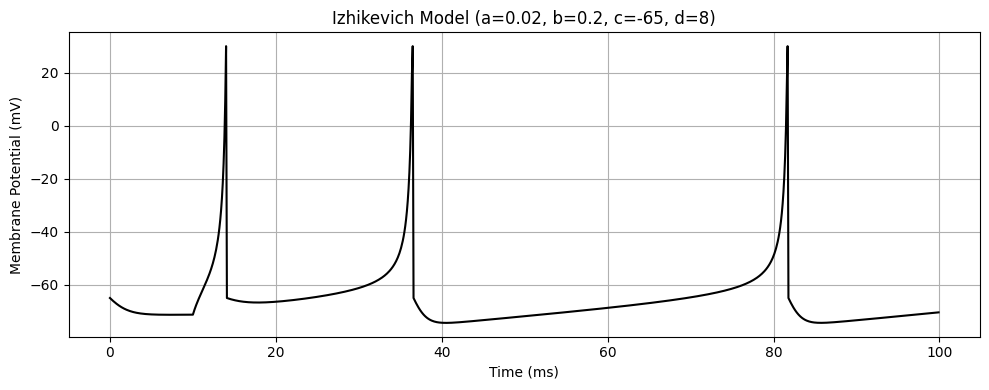

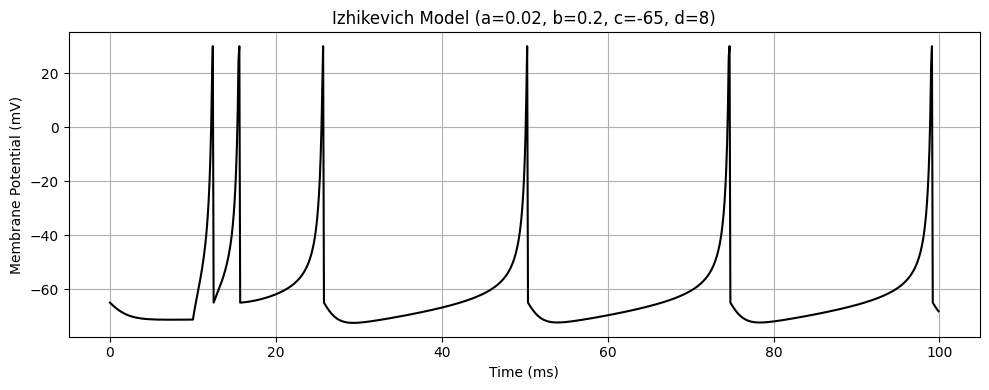

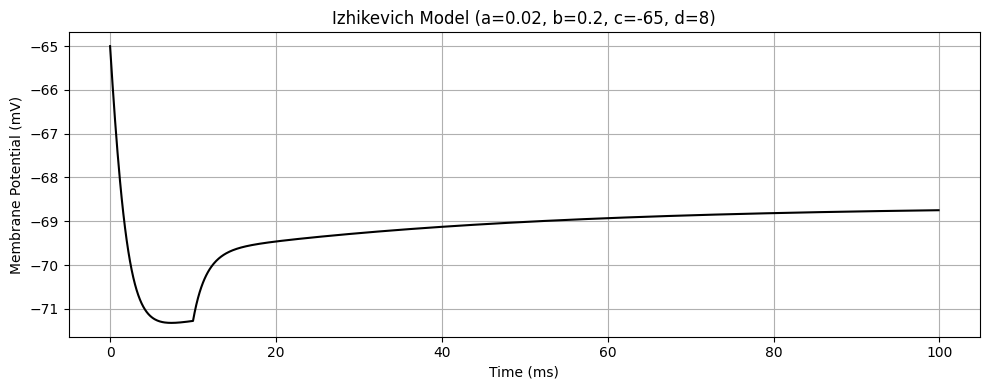

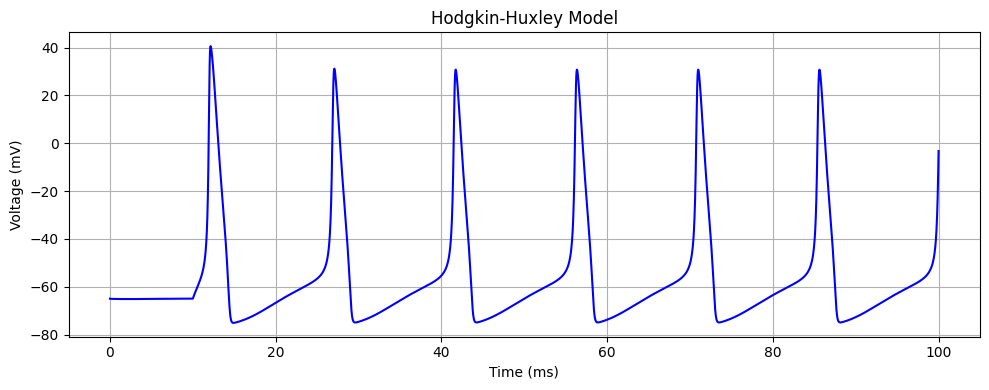

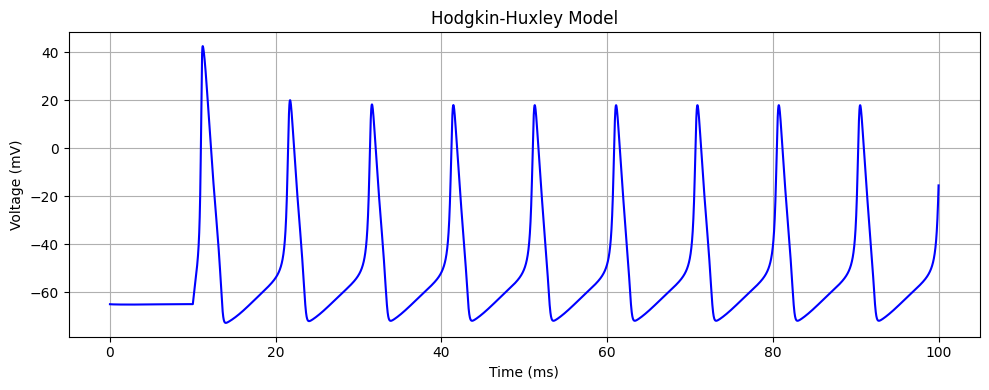

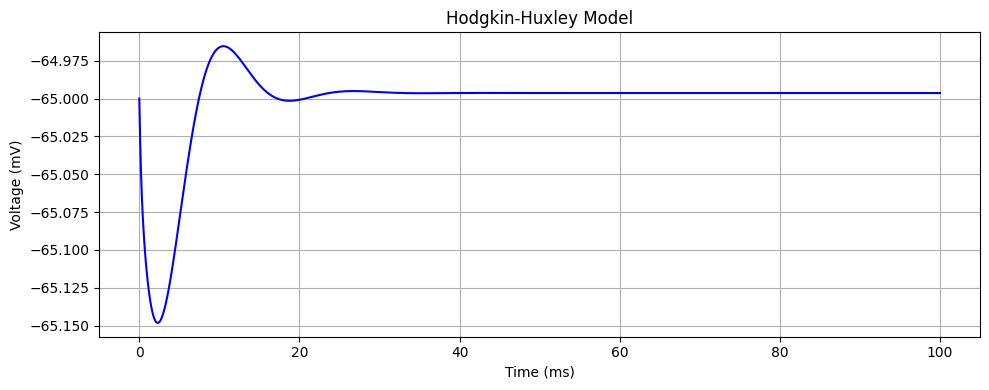

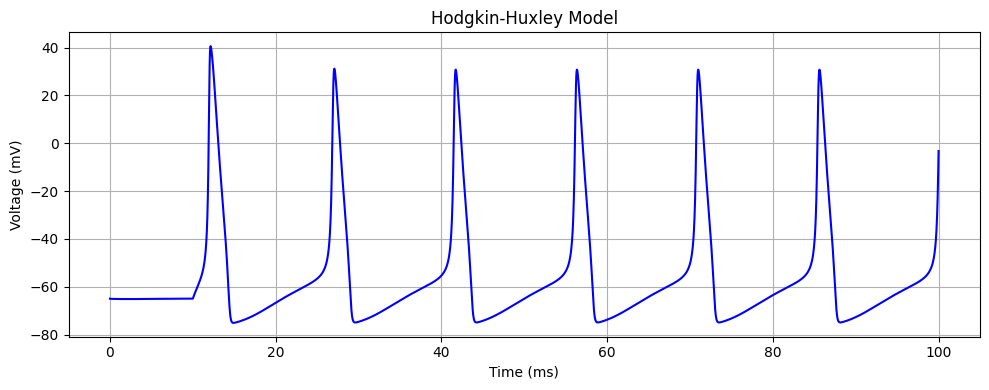

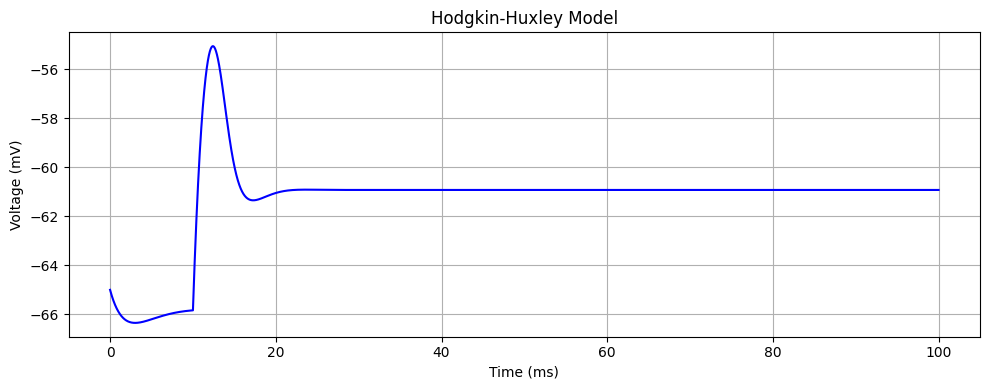

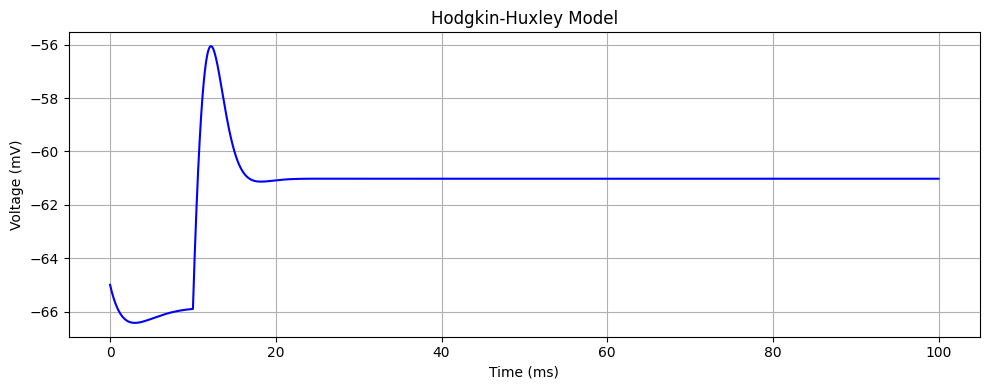

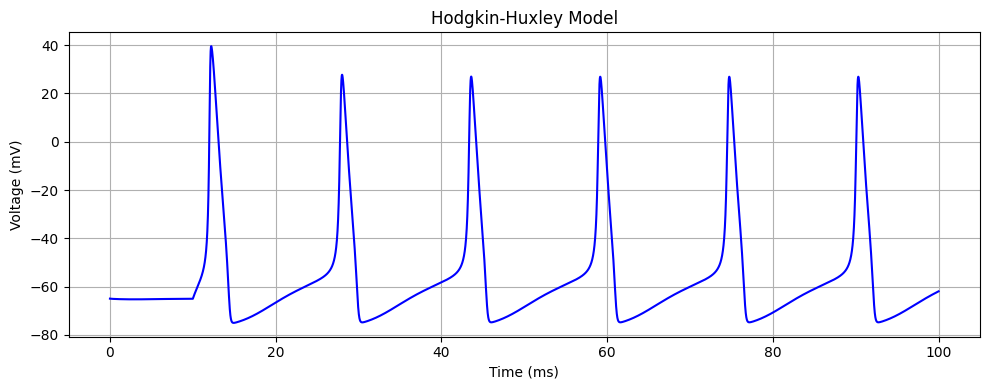

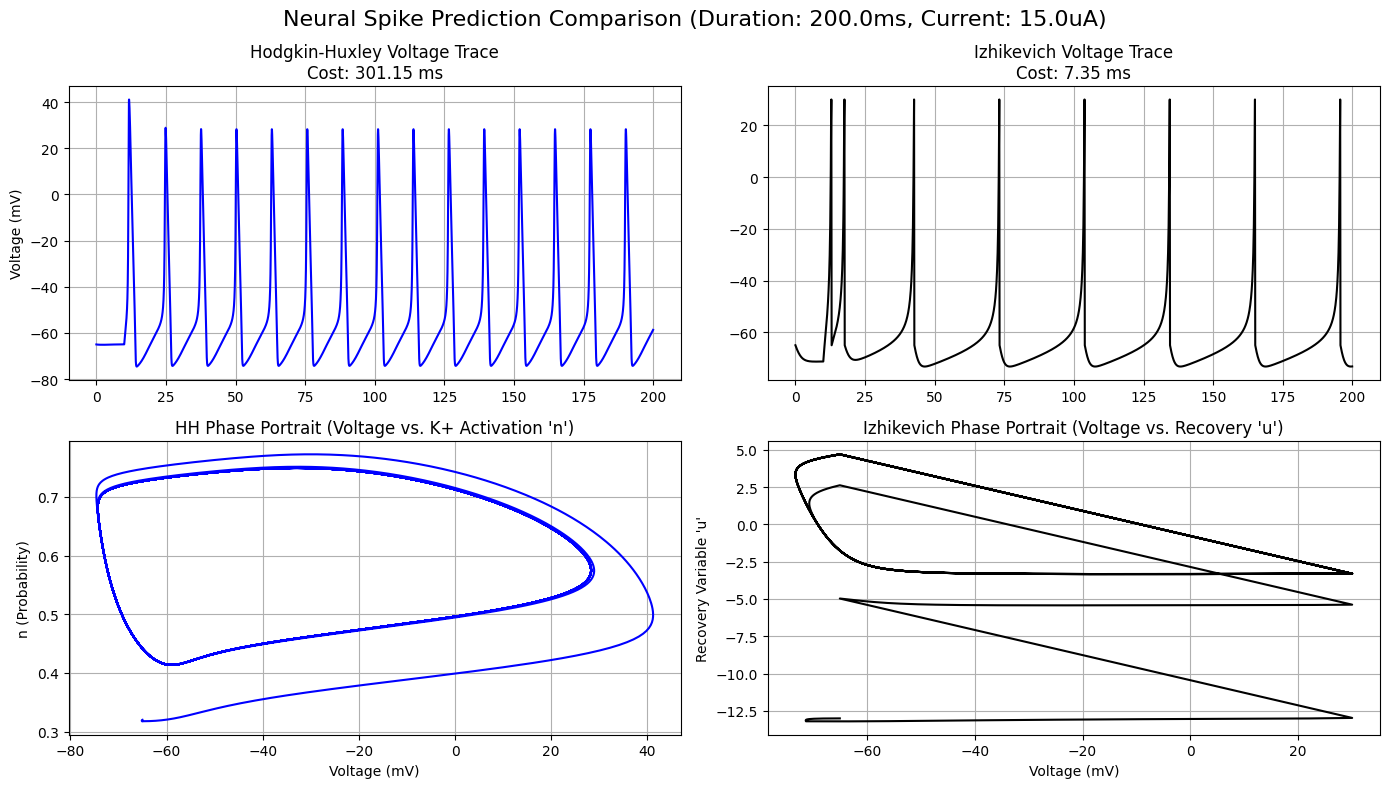

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def run_comparison(I_app=10.0, duration=100.0):
    # --- 1. Izhikevich Model Simulation ---
    start_izh = time.time()
    dt_izh = 0.1  # Izhikevich is stable at larger time steps
    steps_izh = int(duration / dt_izh)
    time_izh = np.arange(0, duration, dt_izh)

    v = np.zeros(steps_izh)
    u = np.zeros(steps_izh)
    v[0] = -65.0
    u[0] = 0.2 * v[0]

    I_izh = np.zeros(steps_izh)
    I_izh[int(10/dt_izh):] = I_app

    for i in range(steps_izh - 1):
        if v[i] >= 30.0:
            v[i] = 30.0
            v[i+1] = -65.0
            u[i+1] = u[i] + 8.0
        else:
            dv = (0.04 * v[i]**2) + (5 * v[i]) + 140 - u[i] + I_izh[i]
            du = 0.02 * (0.2 * v[i] - u[i])
            v[i+1] = v[i] + dv * dt_izh
            u[i+1] = u[i] + du * dt_izh

    time_izh_cost = (time.time() - start_izh) * 1000  # Convert to ms

    # --- 2. Hodgkin-Huxley Model Simulation ---
    start_hh = time.time()
    dt_hh = 0.01  # HH requires very small steps for exponential stability
    steps_hh = int(duration / dt_hh)
    time_hh = np.arange(0, duration, dt_hh)

    V = np.zeros(steps_hh)
    m, h, n = np.zeros(steps_hh), np.zeros(steps_hh), np.zeros(steps_hh)
    V[0] = -65.0
    m[0], h[0], n[0] = 0.05, 0.6, 0.32

    I_hh = np.zeros(steps_hh)
    I_hh[int(10/dt_hh):] = I_app

    for i in range(steps_hh - 1):
        a_m = 0.1 * (V[i] + 40.0) / (1.0 - np.exp(-(V[i] + 40.0) / 10.0)) if V[i] != -40.0 else 1.0
        b_m = 4.0 * np.exp(-(V[i] + 65.0) / 18.0)
        a_h = 0.07 * np.exp(-(V[i] + 65.0) / 20.0)
        b_h = 1.0 / (1.0 + np.exp(-(V[i] + 35.0) / 10.0))
        a_n = 0.01 * (V[i] + 55.0) / (1.0 - np.exp(-(V[i] + 55.0) / 10.0)) if V[i] != -55.0 else 0.1
        b_n = 0.125 * np.exp(-(V[i] + 65.0) / 80.0)

        I_Na = 120.0 * (m[i]**3) * h[i] * (V[i] - 50.0)
        I_K = 36.0 * (n[i]**4) * (V[i] - (-77.0))
        I_L = 0.3 * (V[i] - (-54.387))

        V[i+1] = V[i] + dt_hh * (I_hh[i] - (I_Na + I_K + I_L))
        m[i+1] = m[i] + dt_hh * (a_m * (1.0 - m[i]) - b_m * m[i])
        h[i+1] = h[i] + dt_hh * (a_h * (1.0 - h[i]) - b_h * h[i])
        n[i+1] = n[i] + dt_hh * (a_n * (1.0 - n[i]) - b_n * n[i])

    time_hh_cost = (time.time() - start_hh) * 1000  # Convert to ms

    # --- 3. Plotting the Comparison ---
    fig, axs = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Neural Spike Prediction Comparison (Duration: {duration}ms, Current: {I_app}uA)", fontsize=16)

    # Top Left: HH Voltage
    axs[0, 0].plot(time_hh, V, color='blue')
    axs[0, 0].set_title(f"Hodgkin-Huxley Voltage Trace\nCost: {time_hh_cost:.2f} ms")
    axs[0, 0].set_ylabel("Voltage (mV)")
    axs[0, 0].grid(True)

    # Top Right: Izhikevich Voltage
    axs[0, 1].plot(time_izh, v, color='black')
    axs[0, 1].set_title(f"Izhikevich Voltage Trace\nCost: {time_izh_cost:.2f} ms")
    axs[0, 1].grid(True)

    # Bottom Left: HH Phase Portrait (V vs n)
    axs[1, 0].plot(V, n, color='blue')
    axs[1, 0].set_title("HH Phase Portrait (Voltage vs. K+ Activation 'n')")
    axs[1, 0].set_xlabel("Voltage (mV)")
    axs[1, 0].set_ylabel("n (Probability)")
    axs[1, 0].grid(True)

    # Bottom Right: Izhikevich Phase Portrait (v vs u)
    axs[1, 1].plot(v, u, color='black')
    axs[1, 1].set_title("Izhikevich Phase Portrait (Voltage vs. Recovery 'u')")
    axs[1, 1].set_xlabel("Voltage (mV)")
    axs[1, 1].set_ylabel("Recovery Variable 'u'")
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

# Run the simulation
run_comparison(I_app=15.0, duration=200.0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import gradio as gr

def live_comparison(I_app, duration):
    # --- Izhikevich Simulation ---
    start_izh = time.time()
    dt_izh = 0.1
    steps_izh = int(duration / dt_izh)
    time_izh = np.arange(0, duration, dt_izh)
    v = np.zeros(steps_izh)
    u = np.zeros(steps_izh)
    v[0] = -65.0
    u[0] = 0.2 * v[0]
    I_izh = np.zeros(steps_izh)
    start_idx_izh = int(10 / dt_izh)
    if start_idx_izh < steps_izh: I_izh[start_idx_izh:] = I_app

    for i in range(steps_izh - 1):
        if v[i] >= 30.0:
            v[i] = 30.0
            v[i+1] = -65.0
            u[i+1] = u[i] + 8.0
        else:
            dv = (0.04 * v[i]**2) + (5 * v[i]) + 140 - u[i] + I_izh[i]
            du = 0.02 * (0.2 * v[i] - u[i])
            v[i+1] = v[i] + dv * dt_izh
            u[i+1] = u[i] + du * dt_izh
    time_izh_cost = (time.time() - start_izh) * 1000

    # --- Hodgkin-Huxley Simulation ---
    start_hh = time.time()
    dt_hh = 0.01
    steps_hh = int(duration / dt_hh)
    time_hh = np.arange(0, duration, dt_hh)
    V = np.zeros(steps_hh)
    m, h, n = np.zeros(steps_hh), np.zeros(steps_hh), np.zeros(steps_hh)
    V[0] = -65.0
    m[0], h[0], n[0] = 0.05, 0.6, 0.32
    I_hh = np.zeros(steps_hh)
    start_idx_hh = int(10 / dt_hh)
    if start_idx_hh < steps_hh: I_hh[start_idx_hh:] = I_app

    for i in range(steps_hh - 1):
        a_m = 0.1 * (V[i] + 40.0) / (1.0 - np.exp(-(V[i] + 40.0) / 10.0)) if V[i] != -40.0 else 1.0
        b_m = 4.0 * np.exp(-(V[i] + 65.0) / 18.0)
        a_h = 0.07 * np.exp(-(V[i] + 65.0) / 20.0)
        b_h = 1.0 / (1.0 + np.exp(-(V[i] + 35.0) / 10.0))
        a_n = 0.01 * (V[i] + 55.0) / (1.0 - np.exp(-(V[i] + 55.0) / 10.0)) if V[i] != -55.0 else 0.1
        b_n = 0.125 * np.exp(-(V[i] + 65.0) / 80.0)

        I_Na = 120.0 * (m[i]**3) * h[i] * (V[i] - 50.0)
        I_K = 36.0 * (n[i]**4) * (V[i] - (-77.0))
        I_L = 0.3 * (V[i] - (-54.387))

        V[i+1] = V[i] + dt_hh * (I_hh[i] - (I_Na + I_K + I_L))
        m[i+1] = m[i] + dt_hh * (a_m * (1.0 - m[i]) - b_m * m[i])
        h[i+1] = h[i] + dt_hh * (a_h * (1.0 - h[i]) - b_h * h[i])
        n[i+1] = n[i] + dt_hh * (a_n * (1.0 - n[i]) - b_n * n[i])
    time_hh_cost = (time.time() - start_hh) * 1000

    # --- Plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(12, 7))

    axs[0, 0].plot(time_hh, V, color='blue')
    axs[0, 0].set_title("HH Voltage Trace")
    axs[0, 0].set_ylabel("Voltage (mV)")

    axs[0, 1].plot(time_izh, v, color='black')
    axs[0, 1].set_title("Izhikevich Voltage Trace")

    axs[1, 0].plot(V, n, color='blue')
    axs[1, 0].set_title("HH Phase: Voltage vs 'n'")
    axs[1, 0].set_xlabel("Voltage (mV)")

    axs[1, 1].plot(v, u, color='black')
    axs[1, 1].set_title("Izhikevich Phase: Voltage vs 'u'")
    axs[1, 1].set_xlabel("Voltage (mV)")

    plt.tight_layout()

    # Cost comparison text
    speedup = time_hh_cost / time_izh_cost if time_izh_cost > 0 else float('inf')
    cost_text = (f"### Computational Cost Analysis\n"
                 f"* **Hodgkin-Huxley Execution Time:** {time_hh_cost:.2f} ms\n"
                 f"* **Izhikevich Execution Time:** {time_izh_cost:.2f} ms\n\n"
                 f"**Result:** The Izhikevich model is approximately **{speedup:.1f}x faster** to compute.")

    return fig, cost_text

# Build Gradio App
with gr.Blocks(theme=gr.themes.Soft()) as comparison_app:
    gr.Markdown("## Live Model Comparison: Hodgkin-Huxley vs Izhikevich")

    with gr.Row():
        with gr.Column(scale=1):
            I_slider = gr.Slider(0, 50, value=15, step=1, label="Applied Current (uA)")
            dur_slider = gr.Slider(50, 500, value=200, step=10, label="Simulation Duration (ms)")
            run_btn = gr.Button("Run Comparison", variant="primary")
            cost_output = gr.Markdown("Run the simulation to see the computational cost.")

        with gr.Column(scale=3):
            plot_output = gr.Plot(label="Side-by-Side Analysis")

    run_btn.click(
        fn=live_comparison,
        inputs=[I_slider, dur_slider],
        outputs=[plot_output, cost_output]
    )

comparison_app.launch(share=False)

/tmp/ipython-input-308/2495739311.py:93: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as comparison_app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

Plot saved successfully as: comparative_spike_plot.png


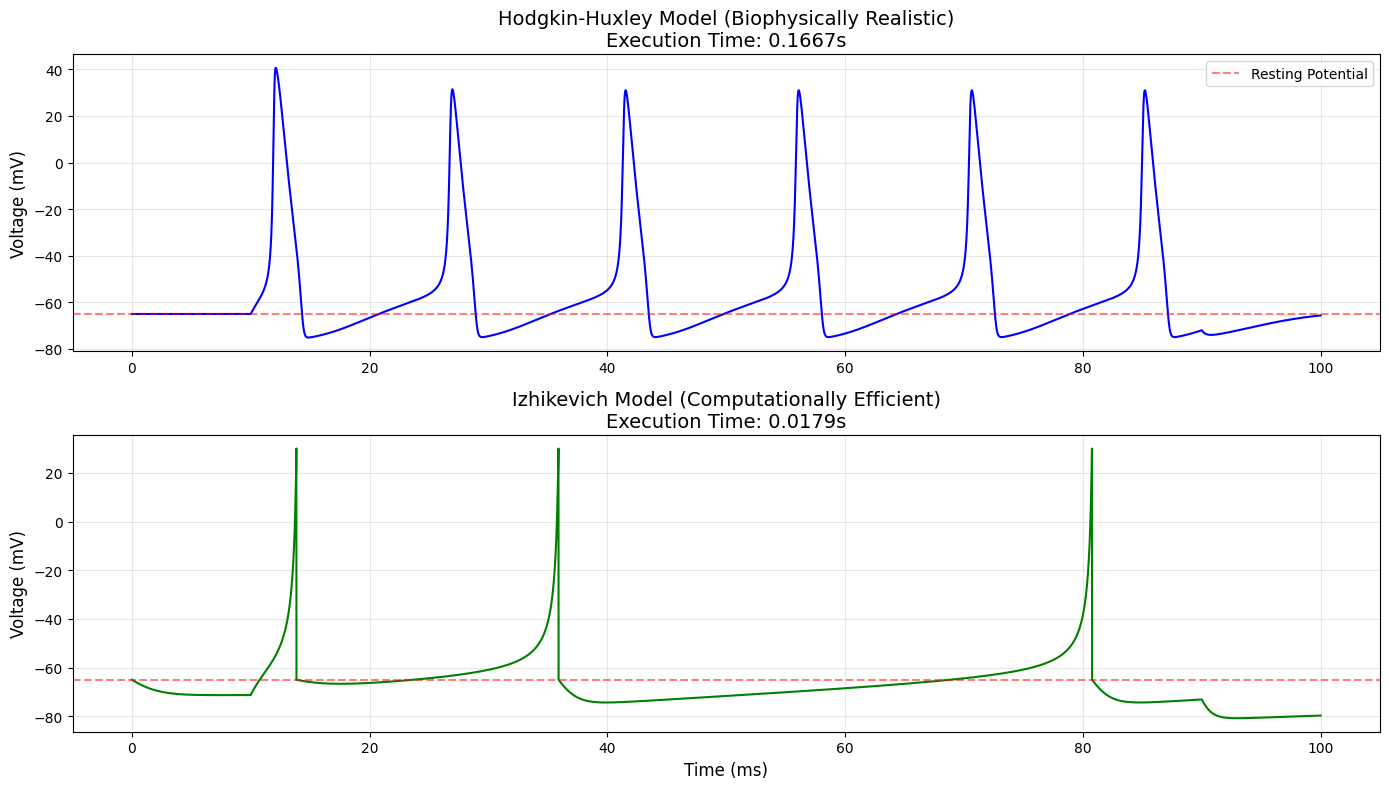

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==============================================================================
# 1. HODGKIN-HUXLEY MODEL
# ==============================================================================
class HodgkinHuxley:
    def __init__(self):
        # Biophysical Parameters
        self.C_m  = 1.0
        self.g_Na = 120.0
        self.g_K  = 36.0
        self.g_L  = 0.3
        self.E_Na = 50.0
        self.E_K  = -77.0
        self.E_L  = -54.387

    def vtrap(self, x, y):
        if abs(x/y) < 1e-6:
            return y * (1 - x/y/2)
        return x / (np.exp(x/y) - 1)

    def alpha_m(self, V): return 0.1 * self.vtrap(-(V + 40), 10)
    def beta_m(self, V):  return 4.0 * np.exp(-(V + 65) / 18)
    def alpha_h(self, V): return 0.07 * np.exp(-(V + 65) / 20)
    def beta_h(self, V):  return 1.0 / (1 + np.exp(-(V + 35) / 10))
    def alpha_n(self, V): return 0.01 * self.vtrap(-(V + 55), 10)
    def beta_n(self, V):  return 0.125 * np.exp(-(V + 65) / 80)

    def simulate(self, I_amp, T, dt):
        t = np.arange(0, T, dt)
        V = np.zeros_like(t)
        m = np.zeros_like(t)
        h = np.zeros_like(t)
        n = np.zeros_like(t)

        # Initial Conditions (Resting State)
        V[0] = -65.0
        m[0] = self.alpha_m(V[0]) / (self.alpha_m(V[0]) + self.beta_m(V[0]))
        h[0] = self.alpha_h(V[0]) / (self.alpha_h(V[0]) + self.beta_h(V[0]))
        n[0] = self.alpha_n(V[0]) / (self.alpha_n(V[0]) + self.beta_n(V[0]))

        for i in range(1, len(t)):
            # Apply step current between 10ms and 90ms
            I = I_amp if (10.0 <= t[i] <= 90.0) else 0.0

            Vm = V[i-1]
            m[i] = m[i-1] + dt * (self.alpha_m(Vm)*(1-m[i-1]) - self.beta_m(Vm)*m[i-1])
            h[i] = h[i-1] + dt * (self.alpha_h(Vm)*(1-h[i-1]) - self.beta_h(Vm)*h[i-1])
            n[i] = n[i-1] + dt * (self.alpha_n(Vm)*(1-n[i-1]) - self.beta_n(Vm)*n[i-1])

            I_ion = self.g_Na*(m[i]**3)*h[i]*(Vm - self.E_Na) + \
                    self.g_K*(n[i]**4)*(Vm - self.E_K) + \
                    self.g_L*(Vm - self.E_L)

            V[i] = V[i-1] + dt * (I - I_ion) / self.C_m

        return t, V

# ==============================================================================
# 2. IZHIKEVICH MODEL
# ==============================================================================
class Izhikevich:
    def __init__(self):
        # Regular Spiking (RS) Parameters
        self.a = 0.02
        self.b = 0.2
        self.c = -65.0
        self.d = 8.0

    def simulate(self, I_amp, T, dt):
        t = np.arange(0, T, dt)
        V = np.zeros_like(t)
        u = np.zeros_like(t)

        V[0] = -65.0
        u[0] = self.b * V[0]

        for i in range(1, len(t)):
            I = I_amp if (10.0 <= t[i] <= 90.0) else 0.0

            v_curr = V[i-1]
            u_curr = u[i-1]

            v_next = v_curr + dt * (0.04*v_curr**2 + 5*v_curr + 140 - u_curr + I)
            u_next = u_curr + dt * (self.a * (self.b*v_curr - u_curr))

            if v_next >= 30.0:
                V[i] = 30.0
                V[i-1] = 30.0
                V[i] = self.c
                u[i] = u_next + self.d
            else:
                V[i] = v_next
                u[i] = u_next

        return t, V

# ==============================================================================
# 3. RUNNER & PLOTTING
# ==============================================================================
# Parameters
T  = 100.0
dt = 0.01
I_input = 10.0

hh_model = HodgkinHuxley()
iz_model = Izhikevich()

# Time HH
start_hh = time.time()
t_hh, v_hh = hh_model.simulate(I_input, T, dt)
end_hh = time.time()
hh_duration = end_hh - start_hh

# Time Izhikevich
start_iz = time.time()
t_iz, v_iz = iz_model.simulate(I_input, T, dt)
end_iz = time.time()
iz_duration = end_iz - start_iz

# Plotting
plt.figure(figsize=(14, 8))

# Subplot 1: HH
plt.subplot(2, 1, 1)
plt.title(f"Hodgkin-Huxley Model (Biophysically Realistic)\nExecution Time: {hh_duration:.4f}s", fontsize=14)
plt.plot(t_hh, v_hh, color='blue', lw=1.5)
plt.ylabel("Voltage (mV)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(-65, color='red', linestyle='--', alpha=0.5, label='Resting Potential')
plt.legend(loc='upper right')

# Subplot 2: Izhikevich
plt.subplot(2, 1, 2)
plt.title(f"Izhikevich Model (Computationally Efficient)\nExecution Time: {iz_duration:.4f}s", fontsize=14)
plt.plot(t_iz, v_iz, color='green', lw=1.5)
plt.ylabel("Voltage (mV)", fontsize=12)
plt.xlabel("Time (ms)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(-65, color='red', linestyle='--', alpha=0.5, label='Resting Potential')

plt.tight_layout()

# Save the image automatically in Colab
image_filename = 'comparative_spike_plot.png'
plt.savefig(image_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully as: {image_filename}")

plt.show()

Plot saved successfully as: image_1151a3.png


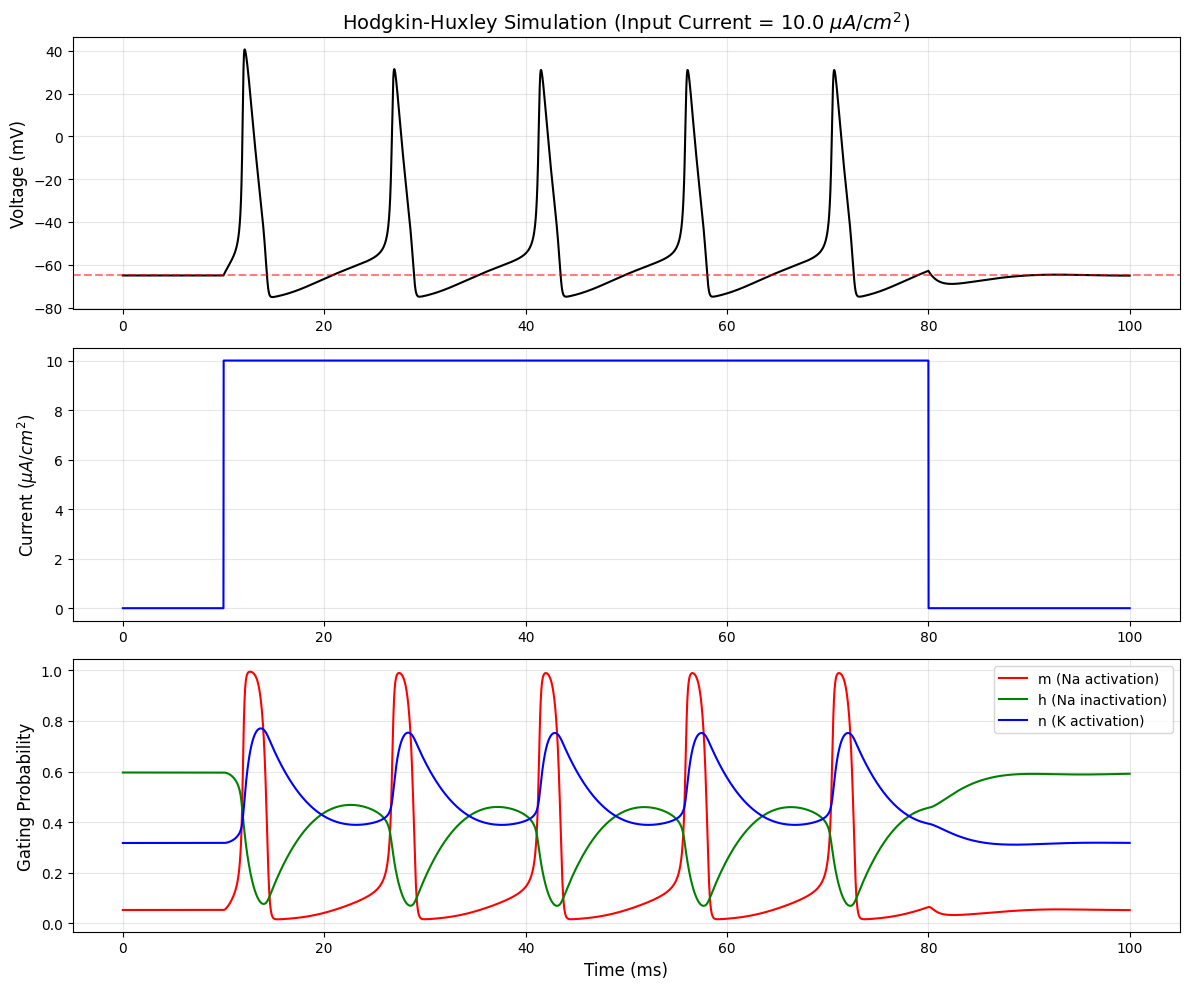

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. HODGKIN-HUXLEY MODEL (Gating Variable Focus)
# ==============================================================================
class HodgkinHuxleyGating:
    def __init__(self):
        # Biophysical Parameters
        self.C_m  = 1.0
        self.g_Na = 120.0
        self.g_K  = 36.0
        self.g_L  = 0.3
        self.E_Na = 50.0
        self.E_K  = -77.0
        self.E_L  = -54.387

    def vtrap(self, x, y):
        if abs(x/y) < 1e-6:
            return y * (1 - x/y/2)
        return x / (np.exp(x/y) - 1)

    def alpha_m(self, V): return 0.1 * self.vtrap(-(V + 40), 10)
    def beta_m(self, V):  return 4.0 * np.exp(-(V + 65) / 18)
    def alpha_h(self, V): return 0.07 * np.exp(-(V + 65) / 20)
    def beta_h(self, V):  return 1.0 / (1 + np.exp(-(V + 35) / 10))
    def alpha_n(self, V): return 0.01 * self.vtrap(-(V + 55), 10)
    def beta_n(self, V):  return 0.125 * np.exp(-(V + 65) / 80)

    def simulate(self, I_amp, T, dt):
        t = np.arange(0, T, dt)
        V = np.zeros_like(t)
        m = np.zeros_like(t)
        h = np.zeros_like(t)
        n = np.zeros_like(t)
        I_inj = np.zeros_like(t)

        # Initial Conditions (Resting State)
        V[0] = -65.0
        m[0] = self.alpha_m(V[0]) / (self.alpha_m(V[0]) + self.beta_m(V[0]))
        h[0] = self.alpha_h(V[0]) / (self.alpha_h(V[0]) + self.beta_h(V[0]))
        n[0] = self.alpha_n(V[0]) / (self.alpha_n(V[0]) + self.beta_n(V[0]))

        for i in range(1, len(t)):
            # Apply step current between 10ms and 80ms to clearly see the start and end
            I = I_amp if (10.0 <= t[i] <= 80.0) else 0.0
            I_inj[i] = I

            Vm = V[i-1]
            # Update gating variables
            m[i] = m[i-1] + dt * (self.alpha_m(Vm)*(1-m[i-1]) - self.beta_m(Vm)*m[i-1])
            h[i] = h[i-1] + dt * (self.alpha_h(Vm)*(1-h[i-1]) - self.beta_h(Vm)*h[i-1])
            n[i] = n[i-1] + dt * (self.alpha_n(Vm)*(1-n[i-1]) - self.beta_n(Vm)*n[i-1])

            # Calculate currents and update voltage
            I_ion = self.g_Na*(m[i]**3)*h[i]*(Vm - self.E_Na) + \
                    self.g_K*(n[i]**4)*(Vm - self.E_K) + \
                    self.g_L*(Vm - self.E_L)

            V[i] = V[i-1] + dt * (I - I_ion) / self.C_m

        return t, V, m, h, n, I_inj

# ==============================================================================
# 2. RUNNER & PLOTTING
# ==============================================================================
# Parameters
T  = 100.0
dt = 0.01
input_current = 10.0

model = HodgkinHuxleyGating()
t, V, m, h, n, I = model.simulate(input_current, T, dt)

# Plotting the 3-panel figure
plt.figure(figsize=(12, 10))

# Plot 1: Voltage
plt.subplot(3, 1, 1)
plt.title(rf'Hodgkin-Huxley Simulation (Input Current = {input_current} $\mu A/cm^2$)', fontsize=14)
plt.plot(t, V, color='black', lw=1.5)
plt.ylabel('Voltage (mV)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(-65, color='red', linestyle='--', alpha=0.5, label='Resting Potential')

# Plot 2: Input Current
plt.subplot(3, 1, 2)
plt.plot(t, I, color='blue', lw=1.5)
plt.ylabel(r'Current ($\mu A/cm^2$)', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 3: Gating Variables (The core focus of this figure)
plt.subplot(3, 1, 3)
plt.plot(t, m, label='m (Na activation)', color='red', lw=1.5)
plt.plot(t, h, label='h (Na inactivation)', color='green', lw=1.5)
plt.plot(t, n, label='n (K activation)', color='blue', lw=1.5)
plt.ylabel('Gating Probability', fontsize=12)
plt.xlabel('Time (ms)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save the image automatically in Colab
image_filename = 'image_1151a3.png'
plt.savefig(image_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully as: {image_filename}")

plt.show()

Initializing Neural Simulation (Duration: 100ms, Current: 10 µA)...
✅ Hodgkin-Huxley computed in:  0.13739 seconds
✅ Izhikevich computed in:      0.01817 seconds
🚀 PERFORMANCE METRIC: Izhikevich is 7.6x faster!



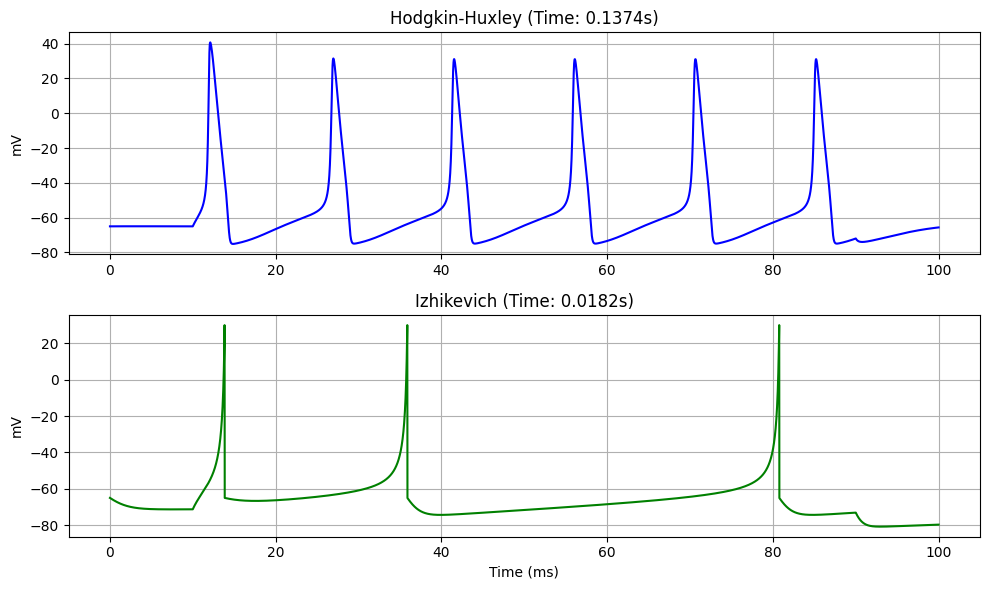

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

class HodgkinHuxley:
    def __init__(self):
        self.C_m, self.g_Na, self.g_K, self.g_L = 1.0, 120.0, 36.0, 0.3
        self.E_Na, self.E_K, self.E_L = 50.0, -77.0, -54.387

    def vtrap(self, x, y):
        return y * (1 - x/y/2) if abs(x/y) < 1e-6 else x / (np.exp(x/y) - 1)

    def simulate(self, I_amp, T, dt):
        t = np.arange(0, T, dt)
        V, m, h, n = np.zeros_like(t), np.zeros_like(t), np.zeros_like(t), np.zeros_like(t)
        V[0] = -65.0
        m[0] = 0.052; h[0] = 0.596; n[0] = 0.317

        for i in range(1, len(t)):
            I = I_amp if (10.0 <= t[i] <= 90.0) else 0.0
            Vm = V[i-1]
            m[i] = m[i-1] + dt * ((0.1 * self.vtrap(-(Vm + 40), 10))*(1-m[i-1]) - (4.0 * np.exp(-(Vm + 65) / 18))*m[i-1])
            h[i] = h[i-1] + dt * ((0.07 * np.exp(-(Vm + 65) / 20))*(1-h[i-1]) - (1.0 / (1 + np.exp(-(Vm + 35) / 10)))*h[i-1])
            n[i] = n[i-1] + dt * ((0.01 * self.vtrap(-(Vm + 55), 10))*(1-n[i-1]) - (0.125 * np.exp(-(Vm + 65) / 80))*n[i-1])
            I_ion = self.g_Na*(m[i]**3)*h[i]*(Vm - self.E_Na) + self.g_K*(n[i]**4)*(Vm - self.E_K) + self.g_L*(Vm - self.E_L)
            V[i] = V[i-1] + dt * (I - I_ion) / self.C_m
        return t, V

class Izhikevich:
    def __init__(self):
        self.a, self.b, self.c, self.d = 0.02, 0.2, -65.0, 8.0

    def simulate(self, I_amp, T, dt):
        t = np.arange(0, T, dt)
        V, u = np.zeros_like(t), np.zeros_like(t)
        V[0], u[0] = -65.0, 0.2 * -65.0

        for i in range(1, len(t)):
            I = I_amp if (10.0 <= t[i] <= 90.0) else 0.0
            v_curr, u_curr = V[i-1], u[i-1]
            v_next = v_curr + dt * (0.04*v_curr**2 + 5*v_curr + 140 - u_curr + I)
            u_next = u_curr + dt * (self.a * (self.b*v_curr - u_curr))

            if v_next >= 30.0:
                V[i], V[i-1], u[i] = self.c, 30.0, u_next + self.d
            else:
                V[i], u[i] = v_next, u_next
        return t, V

# --- LIVE DEMO RUNNER ---
print("Initializing Neural Simulation (Duration: 100ms, Current: 10 µA)...")
time.sleep(1) # Adds a slight dramatic pause for the presentation

hh = HodgkinHuxley()
start_hh = time.perf_counter()
t_hh, v_hh = hh.simulate(10.0, 100.0, 0.01)
hh_time = time.perf_counter() - start_hh
print(f"✅ Hodgkin-Huxley computed in:  {hh_time:.5f} seconds")

iz = Izhikevich()
start_iz = time.perf_counter()
t_iz, v_iz = iz.simulate(10.0, 100.0, 0.01)
iz_time = time.perf_counter() - start_iz
print(f"✅ Izhikevich computed in:      {iz_time:.5f} seconds")

print(f"🚀 PERFORMANCE METRIC: Izhikevich is {hh_time/iz_time:.1f}x faster!\n")

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.plot(t_hh, v_hh, 'b'); ax1.set_title(f"Hodgkin-Huxley (Time: {hh_time:.4f}s)"); ax1.set_ylabel("mV"); ax1.grid(True)
ax2.plot(t_iz, v_iz, 'g'); ax2.set_title(f"Izhikevich (Time: {iz_time:.4f}s)"); ax2.set_ylabel("mV"); ax2.set_xlabel("Time (ms)"); ax2.grid(True)
plt.tight_layout()
plt.show()